# 02 — Random Forest: Pipeline chính

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

## 1. Đọc dữ liệu 

In [2]:
df = pd.read_csv('../dataset/bank-additional-full.csv', sep=';')
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Xử lý pdays = 999

In [3]:
df['pdays_contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].replace(999, -1)

print('Số khách chưa từng được liên hệ trước:', (df['pdays'] == 999).sum())
df[['pdays', 'pdays_clean', 'pdays_contacted_before']].head()

Số khách chưa từng được liên hệ trước: 39673


,pdays,pdays_clean,pdays_contacted_before
0,999,-1,0
1,999,-1,0
2,999,-1,0
3,999,-1,0
4,999,-1,0


## 3. Xử lý giá trị 'unknown'

In [5]:
for col in ['job', 'education', 'housing', 'loan', 'marital', 'default']:
    print(col, '->', (df[col] == 'unknown').sum(), 'giá trị unknown')

job -> 330 giá trị unknown
education -> 1731 giá trị unknown
housing -> 990 giá trị unknown
loan -> 990 giá trị unknown
marital -> 80 giá trị unknown
default -> 8597 giá trị unknown


## 4. Pipeline tiền xử lý và tách train/test

In [7]:
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','day_of_week','poutcome']
num_cols = ['age','campaign','previous','emp.var.rate','cons.price.idx',
            'cons.conf.idx','euribor3m','nr.employed',
            'pdays_clean','pdays_contacted_before']

X = df[cat_cols + num_cols]
y = (df['y'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
], remainder='passthrough')

## 5. Baseline: DummyClassifier + Decision Tree 

In [9]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
print(f'Dummy ROC-AUC: {dummy_auc:.4f}')

tree_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=6, class_weight='balanced',
                                    random_state=RANDOM_STATE))
])
tree_pipe.fit(X_train, y_train)
tree_auc = roc_auc_score(y_test, tree_pipe.predict_proba(X_test)[:, 1])
print(f'Decision Tree đơn ROC-AUC: {tree_auc:.4f}')

Dummy ROC-AUC: 0.5051
Decision Tree đơn ROC-AUC: 0.7917


## 6. Random Forest + OOB Score

In [11]:
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=400,
        max_features='sqrt',
        class_weight='balanced_subsample',
        oob_score=True,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])
rf_pipe.fit(X_train, y_train)

rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
rf_pr_auc = average_precision_score(y_test, rf_proba)
oob = rf_pipe.named_steps['rf'].oob_score_

print(f'Random Forest ROC-AUC : {rf_auc:.4f}')
print(f'Random Forest PR-AUC  : {rf_pr_auc:.4f}')
print(f'OOB score              : {oob:.4f}')
print(f'Cải thiện so với 1 cây đơn: {rf_auc - tree_auc:+.4f} ROC-AUC')
print(classification_report(y_test, (rf_proba >= 0.5).astype(int)))

Random Forest ROC-AUC : 0.7835
Random Forest PR-AUC  : 0.4295
OOB score              : 0.8910
Cải thiện so với 1 cây đơn: -0.0082 ROC-AUC
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.30      0.39       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



## 7. AUC theo `n_estimators` — tìm điểm bão hòa

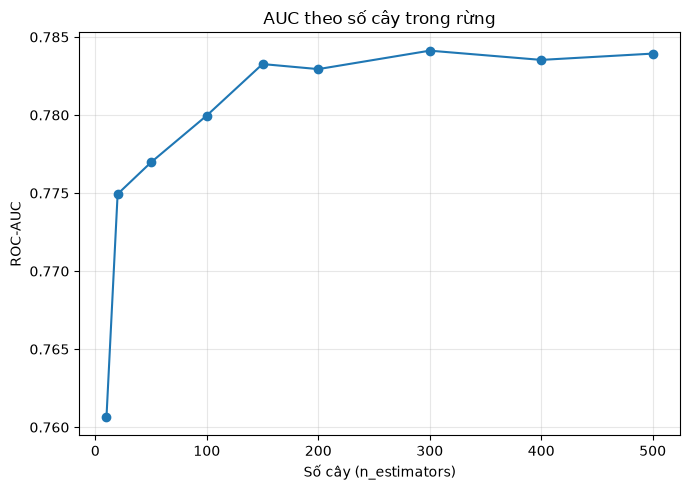

In [12]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

n_range = [10, 20, 50, 100, 150, 200, 300, 400, 500]
aucs = []
for n in n_range:
    rf = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                 class_weight='balanced_subsample',
                                 n_jobs=-1, random_state=RANDOM_STATE)
    rf.fit(X_train_pre, y_train)
    proba = rf.predict_proba(X_test_pre)[:, 1]
    aucs.append(roc_auc_score(y_test, proba))

plt.figure(figsize=(7, 5))
plt.plot(n_range, aucs, marker='o')
plt.xlabel('Số cây (n_estimators)')
plt.ylabel('ROC-AUC')
plt.title('AUC theo số cây trong rừng')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/auc_theo_so_cay.png', dpi=150)
plt.show()

## 8. So sánh feature_importances với permutation_importances

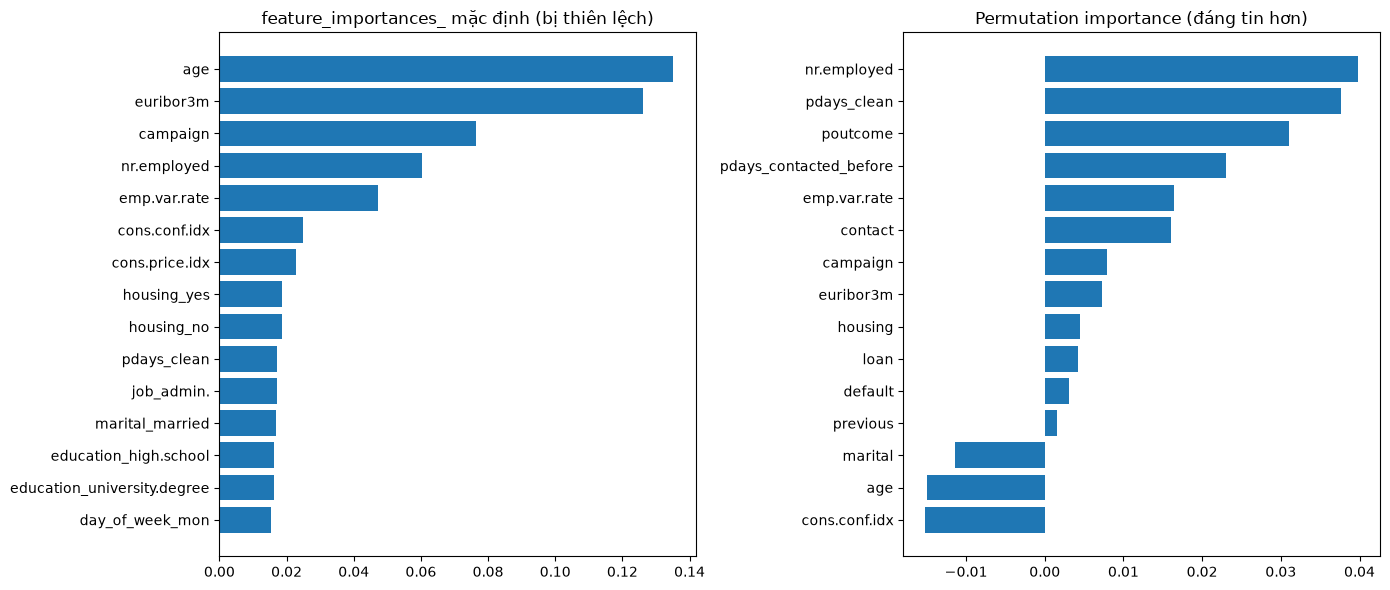

In [14]:
rf = rf_pipe.named_steps['rf']
ohe = rf_pipe.named_steps['pre'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = cat_feature_names + num_cols

df_default = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

df_default

perm = permutation_importance(rf_pipe, X_test, y_test, n_repeats=10,
                               scoring='average_precision',
                               random_state=RANDOM_STATE, n_jobs=-1)

df_perm = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False).head(15)

df_perm

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(df_default['feature'][::-1], df_default['importance'][::-1])
axes[0].set_title('feature_importances_ mặc định (bị thiên lệch)')
axes[1].barh(df_perm['feature'][::-1], df_perm['importance'][::-1])
axes[1].set_title('Permutation importance (đáng tin hơn)')
plt.tight_layout()
plt.savefig('../reports/permutation_importance.png', dpi=150)
plt.show()

## 9. Tính PRECISION@5000 VÀ LIFT

In [15]:
def lift_at_k(y_true, y_proba, k):
    y_true_arr = np.asarray(y_true)
    idx = np.argsort(y_proba)[::-1][:k]
    precision_k = y_true_arr[idx].mean()
    baseline_rate = y_true_arr.mean()
    lift = precision_k / baseline_rate
    return precision_k, lift

k = min(5000, len(y_test))
precision_k, lift = lift_at_k(y_test, rf_proba, k)
print(f'Precision@{k}: {precision_k:.4f}')
print(f'Lift@{k}     : {lift:.2f}x so với gọi ngẫu nhiên')

Precision@5000: 0.1580
Lift@5000     : 1.40x so với gọi ngẫu nhiên


## 10. Vẽ LIFT / Cumulative gain

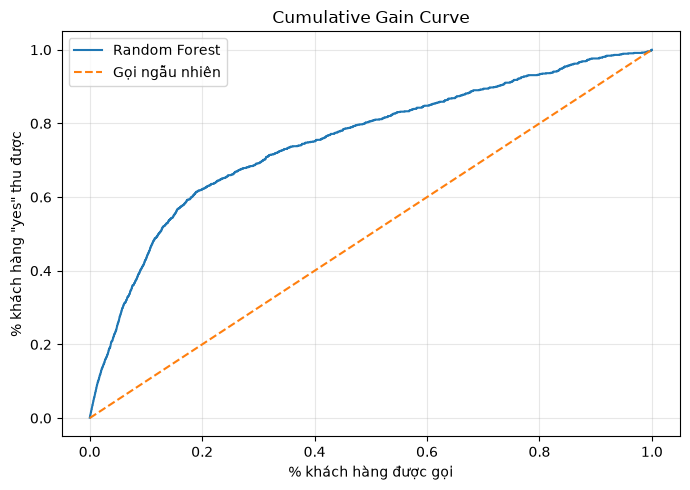

In [16]:
order = np.argsort(rf_proba)[::-1]
y_sorted = np.asarray(y_test)[order]
cum_positive = np.cumsum(y_sorted)
pct_contacted = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
pct_captured = cum_positive / y_sorted.sum()

plt.figure(figsize=(7, 5))
plt.plot(pct_contacted, pct_captured, label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Gọi ngẫu nhiên')
plt.xlabel('% khách hàng được gọi')
plt.ylabel('% khách hàng "yes" thu được')
plt.title('Cumulative Gain Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/lift_curve.png', dpi=150)
plt.show()

## 11. Fit trên toàn bộ dữ liệu và xuất danh sách gọi top 5000

In [17]:
final_pipe = Pipeline([
    ('pre', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=400, max_features='sqrt',
                                   class_weight='balanced_subsample',
                                   n_jobs=-1, random_state=RANDOM_STATE))
])
final_pipe.fit(X, y)

all_proba = final_pipe.predict_proba(X)[:, 1]
df_out = df.copy()
df_out['score'] = all_proba
df_out = df_out.drop(columns=['duration'], errors='ignore')

top5000 = df_out.sort_values('score', ascending=False).head(5000)
top5000.to_csv('../outputs/danh_sach_goi_top5000.csv', index=False)
print(f'Đã lưu {len(top5000)} khách hàng vào outputs/danh_sach_goi_top5000.csv')

joblib.dump(final_pipe, '../models/rf_pipeline.joblib')
print('Đã lưu model vào models/rf_pipeline.joblib')

Đã lưu 5000 khách hàng vào outputs/danh_sach_goi_top5000.csv
Đã lưu model vào models/rf_pipeline.joblib
